# Plot comparativo de anomalias por setup (ClearML) - B-4064A-novos

Notebook reutilizavel para comparar presets de preprocessamento (`baseline`, `moving_average`, `knn`, `moving_average_knn`) usando tasks do ClearML.

Fluxo:
1. Usa task base de `moving_average`.
2. Submete treinos faltantes (opcional) via `train_equipment.py --remote`.
3. Gera os mesmos paineis de plot do notebook original para cada setup.
4. Calcula metricas comparativas (proximidade de falha e falsos positivos) e ranking final.


In [16]:
import re
import sys
import time
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from clearml import Task
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing


In [17]:
# ==============================
# Configuracao
# ==============================
EQUIPMENT_ID = 'B-4064A-novos'
QUEUE = 'default'
USE_FULL_SCORES = True

BASE_TASK_ID_MOVING_AVERAGE = '89d98de34bb642009b0a552b1747b0e1'
PRESETS_TARGET = ['baseline', 'moving_average', 'knn', 'moving_average_knn']
AUTO_SUBMIT_MISSING = True

# Opcional: preencher manualmente task ids ja existentes para evitar submit/espera
PRESET_TASK_IDS = {
    'moving_average': BASE_TASK_ID_MOVING_AVERAGE,
    'baseline': 'f2ba460471bf45639652fc94b6214a7a',
    'knn': 'f1d52184727548bd90be2c4d98ad2971',
    'moving_average_knn': 'd1495d0828d14580ac5ede921184525a',
}

# Eventos
EVENT_DATE_F1 = '2024-08-30 07:58'
EVENT_LABEL_F1 = 'Inicio restricao (30/Ago/2024)'
EVENT_DATE_F2 = '2025-04-07'
EVENT_LABEL_F2 = 'Inicio restricao (07/Abr/2025)'

EVENT_TS_F1 = pd.Timestamp(EVENT_DATE_F1)
EVENT_TS_F2 = pd.Timestamp(EVENT_DATE_F2)

# Janelas de avaliacao e plot (mesmo padrao do notebook original)
WINDOW_F1_ZOOM_START = EVENT_TS_F1 - pd.Timedelta(days=10)
WINDOW_F1_ZOOM_END = EVENT_TS_F1
WINDOW_2025_START = '2025-01-01'
WINDOW_2025_END = '2025-12-31'
WINDOW_F2_ZOOM_START = EVENT_TS_F2 - pd.Timedelta(days=10)
WINDOW_F2_ZOOM_END = EVENT_TS_F2

# Janela para falso positivo/calibracao
CALIB_START = '2025-05-01'
CALIB_END = '2025-12-31'

# Modo automatico de sensibilidade
AUTO_USE_CALIBRATED_SENSITIVITY = True
SENSITIVITY_PRESET = 'conservative'  # 'conservative' | 'balanced' | 'sensitive' | 'custom'
THRESHOLD_OVERRIDE = None
CALIB_PERCENTILES = [95, 97, 98, 99, 99.5, 99.7, 99.9]
CALIB_PERSISTENCE_GRID = [(1, 1), (2, 3), (3, 5), (4, 6)]
TARGET_ALERTS_PER_DAY = 2.0

# Plot/saida
GENERATE_PLOTS = True   # default: plota (somente score)
PLOT_ONLY_SCORES = True  # default: visao resumida somente score
PLOT_MODE = 'separated'  # 'separated' | 'consolidated'
ANOMALY_HIGHLIGHT_STYLE = 'lollipop'  # 'lollipop' | 'big_points'
SAVE_PLOTS = False  # default: nao salva PNG
OUTPUT_DPI = 180
FIGSIZE_WIDTH = 12
PANEL_HEIGHT = 2.5

SAVE_COMPARISON_CSV = True
COMPARISON_CSV_PATH = PROJECT_ROOT / 'notebooks' / 'comparativo_setups_b4064a_novos.csv'

# PERFIL SUGERIDO (rapido)
# GENERATE_PLOTS = False
# PLOT_ONLY_SCORES = True
# SAVE_PLOTS = False
#
# PERFIL COMPLETO (analise visual)
# GENERATE_PLOTS = True
# PLOT_ONLY_SCORES = False
# SAVE_PLOTS = True


In [18]:
def _normalize_scores_df(scores):
    if not isinstance(scores, pd.DataFrame):
        raise TypeError(f'artifact de scores deve ser DataFrame, veio: {type(scores)}')

    required_cols = {'reconstruction_error', 'is_anomaly'}
    missing = required_cols - set(scores.columns)
    if missing:
        raise ValueError(f'colunas faltando em scores: {missing}')

    s = scores.copy()
    s.index = pd.to_datetime(s.index)
    s = s.sort_index()
    s['is_anomaly'] = s['is_anomaly'].astype(bool)
    return s[['reconstruction_error', 'is_anomaly']]


def load_task_outputs(task_id: str, use_full_scores: bool = True):
    task = Task.get_task(task_id=task_id)

    if 'results' not in task.artifacts:
        raise KeyError('artifact results nao encontrado na task')
    results = task.artifacts['results'].get()
    if 'threshold' not in results:
        raise KeyError('campo threshold nao encontrado em results')
    threshold = float(results['threshold'])

    score_artifact_name = None
    if use_full_scores and 'full_scores' in task.artifacts:
        score_artifact_name = 'full_scores'
    elif 'test_scores' in task.artifacts:
        score_artifact_name = 'test_scores'
    elif 'full_scores' in task.artifacts:
        score_artifact_name = 'full_scores'
    else:
        raise KeyError('nenhum artifact de score disponivel (full_scores/test_scores)')

    scores = _normalize_scores_df(task.artifacts[score_artifact_name].get())
    return task, results, threshold, scores, score_artifact_name


def load_plot_base(equipment_id: str):
    config = EQUIPMENT_CONFIGS[equipment_id]
    df_raw = load_equipment_data(equipment_id, from_clearml=False)

    pre_steps = config.pre_split_steps
    if pre_steps:
        df_base, _, _ = run_preprocessing(df_raw, pre_steps, fitted_scaler=None)
    else:
        df_base = df_raw

    df_base = df_base.sort_index()
    df_base.index = pd.to_datetime(df_base.index)
    return df_base, config


def slice_window(df_base, scores, window_start, window_end):
    start_ts = pd.Timestamp(window_start)
    end_ts = pd.Timestamp(window_end)

    dfw = df_base.loc[start_ts:end_ts].copy()
    sw = scores.loc[start_ts:end_ts].copy()

    common_idx = dfw.index.intersection(sw.index)
    if len(common_idx) == 0:
        raise ValueError(f'nao ha intersecao de timestamps na janela {window_start}..{window_end}')

    return dfw.loc[common_idx], sw.loc[common_idx]


def print_preprocessing_confirmation(config):
    print('Preprocessamento aplicado para score/predict:')
    print('  1) Pre-split (base bruta):')
    for step in config.pre_split_steps:
        print(f'     - {step}')

    print('  2) Pos-split/predict (modelo): clip + normalize(robust),')
    print('     usando clip_bounds e scaler ajustados no treino (conforme train_equipment.py).')


def persistence_filter(flags: pd.Series, k: int, n: int) -> pd.Series:
    if k == 1 and n == 1:
        return flags.astype(bool)
    roll = flags.astype(int).rolling(window=n, min_periods=n).sum()
    return (roll >= k).fillna(False).astype(bool)


def choose_sensitivity_params(preset: str):
    preset = str(preset).strip().lower()
    eff_percentiles = list(CALIB_PERCENTILES)
    eff_grid = list(CALIB_PERSISTENCE_GRID)
    eff_target_alerts = float(TARGET_ALERTS_PER_DAY)

    if preset == 'conservative':
        eff_percentiles = [99, 99.5, 99.7, 99.9]
        eff_grid = [(3, 5), (4, 6), (5, 8)]
        eff_target_alerts = 0.5
    elif preset == 'sensitive':
        eff_percentiles = [95, 97, 98, 99]
        eff_grid = [(1, 1), (2, 3), (3, 5)]
        eff_target_alerts = 4.0
    elif preset == 'balanced':
        pass
    elif preset == 'custom':
        pass
    else:
        raise ValueError('SENSITIVITY_PRESET invalido. Use: conservative, balanced, sensitive ou custom')

    return eff_percentiles, eff_grid, eff_target_alerts


def recommend_sensitivity(
    scores: pd.DataFrame,
    calib_start: str,
    calib_end: str,
    calib_percentiles: list[float],
    calib_grid: list[tuple[int, int]],
    target_alerts_per_day: float,
):
    calib = scores.loc[pd.Timestamp(calib_start):pd.Timestamp(calib_end)].copy()
    if calib.empty:
        raise ValueError(f'janela de calibracao vazia: {calib_start}..{calib_end}')

    rows = []
    for p in calib_percentiles:
        thr = float(np.percentile(calib['reconstruction_error'].values, p))
        for (k, n) in calib_grid:
            flags = persistence_filter(scores['reconstruction_error'] > thr, k=k, n=n)
            n_days = max((scores.index.max().normalize() - scores.index.min().normalize()).days + 1, 1)
            alerts_per_day = float(flags.sum()) / float(n_days)
            rows.append({
                'percentile': float(p),
                'threshold': float(thr),
                'k': int(k),
                'n': int(n),
                'alerts_per_day': alerts_per_day,
                'distance_to_target': abs(alerts_per_day - target_alerts_per_day),
            })

    calib_df = pd.DataFrame(rows).sort_values(['distance_to_target', 'alerts_per_day']).reset_index(drop=True)
    best = calib_df.iloc[0]
    return {
        'threshold': float(best['threshold']),
        'k': int(best['k']),
        'n': int(best['n']),
        'percentile': float(best['percentile']),
        'alerts_per_day': float(best['alerts_per_day']),
        'table': calib_df,
    }


def parse_task_id_from_output(text: str) -> str | None:
    m = re.search(r'CLEARML_TASK_ID=([a-f0-9]{32})', text)
    if m:
        return m.group(1)
    m2 = re.search(r'tasks/([a-f0-9]{32})', text)
    if m2:
        return m2.group(1)
    return None


def expected_task_name(equipment_id: str, preset: str) -> str:
    return f'autoencoder-{equipment_id}' if preset == 'baseline' else f'autoencoder-{equipment_id}-{preset}'


def submit_training_remote(equipment_id: str, preset: str, queue: str) -> str:
    cmd = [
        'uv', 'run', 'python', 'scripts/train_equipment.py',
        '--equipment', equipment_id,
        '--remote',
        '--queue', queue,
        '--preprocess-preset', preset,
    ]
    print('Submetendo preset:', preset)
    print('Comando:', ' '.join(cmd))
    proc = subprocess.run(cmd, cwd=str(PROJECT_ROOT), capture_output=True, text=True)
    output = (proc.stdout or '') + '\\n' + (proc.stderr or '')
    if proc.returncode != 0:
        raise RuntimeError(f'Falha ao submeter preset={preset}.\nSaida:\n{output}')

    task_id = parse_task_id_from_output(output)
    if not task_id:
        raise RuntimeError(
            'Nao foi possivel capturar task_id automaticamente apos submit remoto. '
            f'Preset={preset}. Verifique a saida do comando.\n{output}'
        )
    return task_id


def resolve_task_ids_by_preset():
    resolved = {p: PRESET_TASK_IDS.get(p) for p in PRESETS_TARGET}

    if not resolved.get('moving_average'):
        resolved['moving_average'] = BASE_TASK_ID_MOVING_AVERAGE

    for preset in PRESETS_TARGET:
        if resolved.get(preset):
            continue
        if not AUTO_SUBMIT_MISSING:
            raise ValueError(
                f'Preset sem task_id: {preset}. Defina PRESET_TASK_IDS[{preset!r}] ou ative AUTO_SUBMIT_MISSING=True.'
            )
        resolved[preset] = submit_training_remote(EQUIPMENT_ID, preset, QUEUE)

    return resolved


def compute_window_metrics(all_scores: pd.DataFrame, anomaly_flags: pd.Series, start, end):
    sw = all_scores.loc[pd.Timestamp(start):pd.Timestamp(end)]
    fw = anomaly_flags.loc[sw.index]
    n_samples = int(len(sw))
    n_anom = int(fw.sum())
    dens = float(n_anom / n_samples) if n_samples > 0 else 0.0
    return n_samples, n_anom, dens


def compute_score_rank(row: pd.Series) -> float:
    # Peso maior para deteccao perto da falha e penalidade para falso positivo.
    return float(
        2.5 * row['dens_anomalias_prox_falha1']
        + 2.5 * row['dens_anomalias_prox_falha2']
        - 1.5 * row['taxa_fp_2025']
        - 1.0 * row['taxa_fp_2025_calib']
    )



def plot_score_only_panel(
    scores_window: pd.DataFrame,
    threshold_flags: pd.Series,
    anomaly_flags: pd.Series,
    threshold: float,
    threshold_label: str,
    n_anomalies: int,
    event_date: pd.Timestamp,
    event_label: str,
    title: str,
    output_path: Path | None = None,
    dpi: int = 180,
    save_plots: bool = False,
    anomaly_highlight_style: str = 'lollipop',
):
    plt.style.use('seaborn-v0_8-whitegrid')
    highlight_style = str(anomaly_highlight_style).strip().lower()
    if highlight_style not in {'lollipop', 'big_points'}:
        raise ValueError("anomaly_highlight_style invalido. Use: 'lollipop' ou 'big_points'")

    fig_s, ax_s = plt.subplots(1, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * 1.6), sharex=True)
    x = scores_window.index
    y = scores_window['reconstruction_error']

    ax_s.plot(x, y, color='purple', linewidth=0.9, alpha=0.55, label='Score de Anomalia (MSE)')
    ax_s.axhline(threshold, color='red', linestyle='--', linewidth=1.3, label=threshold_label)
    ax_s.fill_between(x, threshold, y, where=(y > threshold), color='red', alpha=0.10)

    idx_thr = scores_window.index[threshold_flags]
    if len(idx_thr) > 0:
        ax_s.scatter(
            idx_thr,
            scores_window.loc[idx_thr, 'reconstruction_error'],
            s=8,
            color='orange',
            alpha=0.20,
            label='Cruzamento bruto (score > threshold)',
            zorder=2,
        )

    idx_pers = scores_window.index[anomaly_flags]
    if len(idx_pers) > 0:
        y_pers = scores_window.loc[idx_pers, 'reconstruction_error']
        if highlight_style == 'lollipop':
            baseline = float(np.nanmin(y)) if len(y) else 0.0
            ax_s.vlines(
                idx_pers,
                ymin=baseline,
                ymax=y_pers.values,
                color='red',
                alpha=0.45,
                linewidth=1.2,
                zorder=4,
                label='Persistencia (lollipop)',
            )
            ax_s.scatter(
                idx_pers,
                y_pers,
                s=44,
                facecolor='red',
                edgecolor='white',
                linewidth=0.9,
                alpha=0.95,
                label='Alerta com persistencia',
                zorder=5,
            )
        else:
            ax_s.scatter(
                idx_pers,
                y_pers,
                s=58,
                facecolor='red',
                edgecolor='white',
                linewidth=1.0,
                alpha=0.95,
                label='Alerta com persistencia (pontos)',
                zorder=5,
            )

    ax_s.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
    ax_s.text(
        0.99,
        0.97,
        f'Anomalias (persistencia): {int(n_anomalies)}',
        transform=ax_s.transAxes,
        ha='right',
        va='top',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.7, edgecolor='gray'),
    )
    ax_s.set_ylabel('Score de Anomalia', fontsize=9)
    ax_s.set_xlabel('Tempo (Data/Hora)', fontsize=10)
    ax_s.tick_params(axis='both', labelsize=8)
    ax_s.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)

    fig_s.suptitle(f'{title} | Score de Anomalia', fontsize=14, fontweight='bold', y=0.995)
    fig_s.tight_layout(rect=[0, 0, 1, 0.96])

    saved_paths = []
    if save_plots:
        if output_path is None:
            raise ValueError('output_path eh obrigatorio quando save_plots=True')
        output_path.parent.mkdir(parents=True, exist_ok=True)
        target = output_path.with_name(f"{output_path.stem}_score{output_path.suffix}")
        fig_s.savefig(target, dpi=dpi, bbox_inches='tight')
        saved_paths.append(target)

    plt.show()
    return saved_paths


In [19]:
def plot_anomaly_panels(
    df_window: pd.DataFrame,
    scores_window: pd.DataFrame,
    threshold_flags: pd.Series,
    anomaly_flags: pd.Series,
    threshold: float,
    threshold_label: str,
    n_anomalies: int,
    event_date: pd.Timestamp,
    event_label: str,
    title: str,
    output_path: Path | None = None,
    dpi: int = 180,
    plot_mode: str = 'separated',
    save_plots: bool = False,
    anomaly_highlight_style: str = 'lollipop',
):
    plt.style.use('seaborn-v0_8-whitegrid')

    mode = str(plot_mode).strip().lower()
    if mode not in {'separated', 'consolidated'}:
        raise ValueError("plot_mode invalido. Use: 'separated' ou 'consolidated'")

    highlight_style = str(anomaly_highlight_style).strip().lower()
    if highlight_style not in {'lollipop', 'big_points'}:
        raise ValueError("anomaly_highlight_style invalido. Use: 'lollipop' ou 'big_points'")

    saved_paths = []
    sensors = list(df_window.columns)
    anomaly_idx = scores_window.index[anomaly_flags]

    def maybe_save(fig, suffix: str | None = None):
        if not save_plots:
            return None
        if output_path is None:
            raise ValueError('output_path eh obrigatorio quando save_plots=True')
        output_path.parent.mkdir(parents=True, exist_ok=True)
        if suffix:
            target = output_path.with_name(f"{output_path.stem}_{suffix}{output_path.suffix}")
        else:
            target = output_path
        fig.savefig(target, dpi=dpi, bbox_inches='tight')
        saved_paths.append(target)
        return target

    if mode == 'separated':
        for col in sensors:
            fig, ax = plt.subplots(1, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * 1.4), sharex=True)
            ax.plot(
                df_window.index,
                df_window[col],
                color='steelblue',
                linewidth=1.0,
                alpha=0.85,
                label=f'Serie Temporal: {col}',
            )

            anom_vals = df_window[col].reindex(anomaly_idx).dropna()
            if not anom_vals.empty:
                ax.scatter(
                    anom_vals.index,
                    anom_vals.values,
                    s=28,
                    color='red',
                    edgecolor='none',
                    zorder=4,
                    label='Anomalia',
                )

            ax.axvline(
                event_date,
                color='orange',
                linestyle='--',
                linewidth=1.4,
                label=event_label,
            )
            ax.set_ylabel(col, fontsize=9)
            ax.set_xlabel('Tempo (Data/Hora)', fontsize=10)
            ax.tick_params(axis='both', labelsize=8)
            ax.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)

            fig.suptitle(f'{title} | {col}', fontsize=14, fontweight='bold', y=0.995)
            fig.tight_layout(rect=[0, 0, 1, 0.96])
            sensor_slug = ''.join(ch if ch.isalnum() else '_' for ch in str(col)).strip('_').lower()
            maybe_save(fig, suffix=f'sensor_{sensor_slug}' if sensor_slug else 'sensor')
            plt.show()

        fig_s, ax_s = plt.subplots(1, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * 1.6), sharex=True)
        x = scores_window.index
        y = scores_window['reconstruction_error']
        ax_s.plot(x, y, color='purple', linewidth=0.9, alpha=0.55, label='Score de Anomalia (MSE)')
        ax_s.axhline(
            threshold,
            color='red',
            linestyle='--',
            linewidth=1.3,
            label=threshold_label,
        )
        ax_s.fill_between(x, threshold, y, where=(y > threshold), color='red', alpha=0.10)
        idx_thr = scores_window.index[threshold_flags]
        if len(idx_thr) > 0:
            ax_s.scatter(
                idx_thr,
                scores_window.loc[idx_thr, 'reconstruction_error'],
                s=8,
                color='orange',
                alpha=0.20,
                label='Cruzamento bruto (score > threshold)',
                zorder=2,
            )
        idx_pers = scores_window.index[anomaly_flags]
        if len(idx_pers) > 0:
            y_pers = scores_window.loc[idx_pers, 'reconstruction_error']
            if highlight_style == 'lollipop':
                baseline = float(np.nanmin(y)) if len(y) else 0.0
                ax_s.vlines(
                    idx_pers,
                    ymin=baseline,
                    ymax=y_pers.values,
                    color='red',
                    alpha=0.45,
                    linewidth=1.2,
                    zorder=4,
                    label='Persistencia (lollipop)',
                )
                ax_s.scatter(
                    idx_pers,
                    y_pers,
                    s=44,
                    facecolor='red',
                    edgecolor='white',
                    linewidth=0.9,
                    alpha=0.95,
                    label='Alerta com persistencia',
                    zorder=5,
                )
            else:
                ax_s.scatter(
                    idx_pers,
                    y_pers,
                    s=58,
                    facecolor='red',
                    edgecolor='white',
                    linewidth=1.0,
                    alpha=0.95,
                    label='Alerta com persistencia (pontos)',
                    zorder=5,
                )
        ax_s.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
        ax_s.text(
            0.99,
            0.97,
            f'Anomalias (persistencia): {int(n_anomalies)}',
            transform=ax_s.transAxes,
            ha='right',
            va='top',
            fontsize=8,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.7, edgecolor='gray'),
        )
        ax_s.set_ylabel('Score de Anomalia', fontsize=9)
        ax_s.set_xlabel('Tempo (Data/Hora)', fontsize=10)
        ax_s.tick_params(axis='both', labelsize=8)
        ax_s.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)

        fig_s.suptitle(f'{title} | Score de Anomalia', fontsize=14, fontweight='bold', y=0.995)
        fig_s.tight_layout(rect=[0, 0, 1, 0.96])
        maybe_save(fig_s, suffix='score')
        plt.show()
        return saved_paths

    n_rows = len(sensors) + 1
    fig, axes = plt.subplots(
        n_rows,
        1,
        figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * n_rows),
        sharex=True,
        gridspec_kw={'height_ratios': [1] * len(sensors) + [0.95]},
    )

    for i, col in enumerate(sensors):
        ax = axes[i]
        ax.plot(
            df_window.index,
            df_window[col],
            color='steelblue',
            linewidth=1.0,
            alpha=0.85,
            label=f'Serie Temporal: {col}',
        )

        anom_vals = df_window[col].reindex(anomaly_idx).dropna()
        if not anom_vals.empty:
            ax.scatter(
                anom_vals.index,
                anom_vals.values,
                s=28,
                color='red',
                edgecolor='none',
                zorder=4,
                label='Anomalia',
            )

        ax.axvline(
            event_date,
            color='orange',
            linestyle='--',
            linewidth=1.4,
            label=event_label,
        )
        ax.set_ylabel(col, fontsize=9)
        ax.tick_params(axis='both', labelsize=8)
        ax.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)

    ax_s = axes[-1]
    x = scores_window.index
    y = scores_window['reconstruction_error']
    ax_s.plot(x, y, color='purple', linewidth=0.9, alpha=0.55, label='Score de Anomalia (MSE)')
    ax_s.axhline(
        threshold,
        color='red',
        linestyle='--',
        linewidth=1.3,
        label=threshold_label,
    )
    ax_s.fill_between(x, threshold, y, where=(y > threshold), color='red', alpha=0.10)
    idx_thr = scores_window.index[threshold_flags]
    if len(idx_thr) > 0:
        ax_s.scatter(
            idx_thr,
            scores_window.loc[idx_thr, 'reconstruction_error'],
            s=8,
            color='orange',
            alpha=0.20,
            label='Cruzamento bruto (score > threshold)',
            zorder=2,
        )
    idx_pers = scores_window.index[anomaly_flags]
    if len(idx_pers) > 0:
        y_pers = scores_window.loc[idx_pers, 'reconstruction_error']
        if highlight_style == 'lollipop':
            baseline = float(np.nanmin(y)) if len(y) else 0.0
            ax_s.vlines(
                idx_pers,
                ymin=baseline,
                ymax=y_pers.values,
                color='red',
                alpha=0.45,
                linewidth=1.2,
                zorder=4,
                label='Persistencia (lollipop)',
            )
            ax_s.scatter(
                idx_pers,
                y_pers,
                s=44,
                facecolor='red',
                edgecolor='white',
                linewidth=0.9,
                alpha=0.95,
                label='Alerta com persistencia',
                zorder=5,
            )
        else:
            ax_s.scatter(
                idx_pers,
                y_pers,
                s=58,
                facecolor='red',
                edgecolor='white',
                linewidth=1.0,
                alpha=0.95,
                label='Alerta com persistencia (pontos)',
                zorder=5,
            )
    ax_s.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
    ax_s.text(
        0.99,
        0.97,
        f'Anomalias (persistencia): {int(n_anomalies)}',
        transform=ax_s.transAxes,
        ha='right',
        va='top',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.7, edgecolor='gray'),
    )
    ax_s.set_ylabel('Score de Anomalia', fontsize=9)
    ax_s.set_xlabel('Tempo (Data/Hora)', fontsize=10)
    ax_s.tick_params(axis='both', labelsize=8)
    ax_s.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)

    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.99])
    maybe_save(fig)
    plt.show()
    return saved_paths


Preprocessamento aplicado para score/predict:
  1) Pre-split (base bruta):
     - {'step': 'remove_sensor_errors', 'error_values': [-25.0]}
     - {'step': 'resample', 'freq': '1h'}
  2) Pos-split/predict (modelo): clip + normalize(robust),
     usando clip_bounds e scaler ajustados no treino (conforme train_equipment.py).

Mapa preset -> task_id resolvido:
  - baseline: f2ba460471bf45639652fc94b6214a7a
  - moving_average: 89d98de34bb642009b0a552b1747b0e1
  - knn: f1d52184727548bd90be2c4d98ad2971
  - moving_average_knn: d1495d0828d14580ac5ede921184525a

Preset: baseline | Task: f2ba460471bf45639652fc94b6214a7a | Artifact de score: full_scores
Threshold em results: 0.044684
Sensibilidade calibrada: threshold=0.165013, percentile=99.0, k=3, n=5, alerts/day=0.023


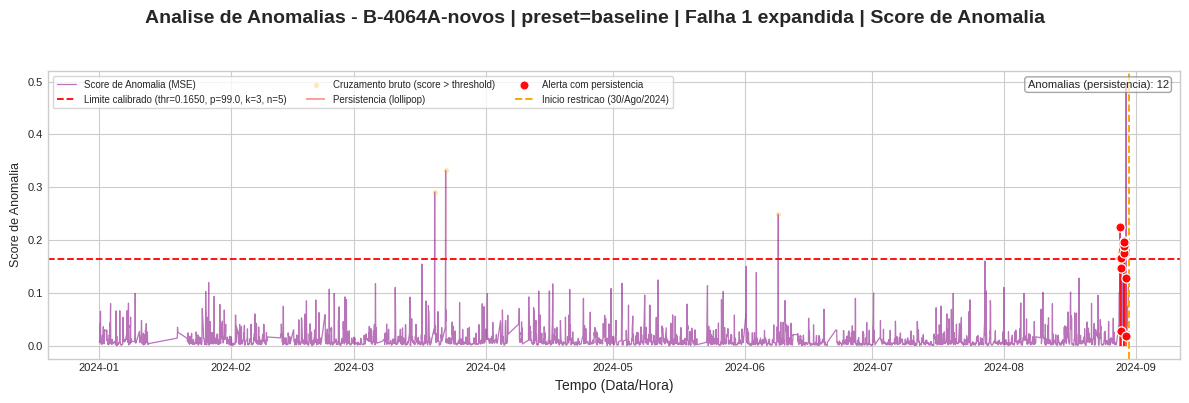

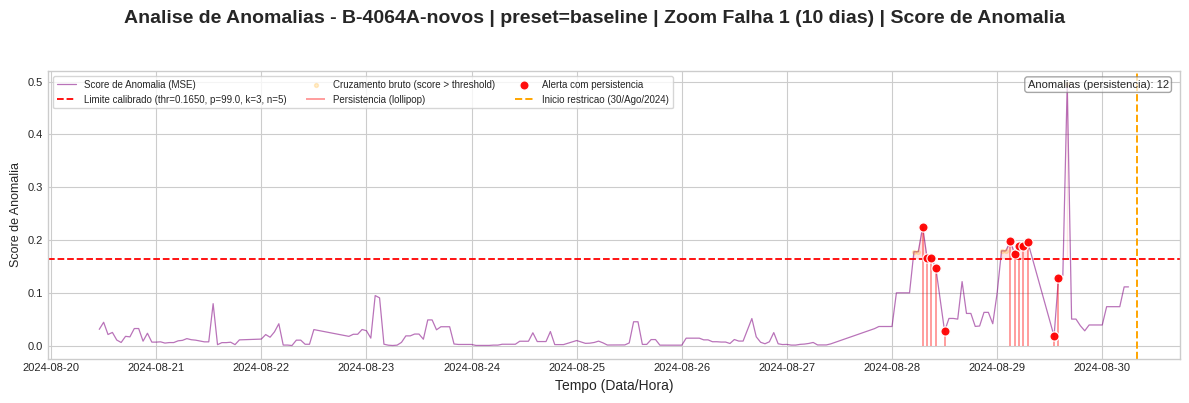

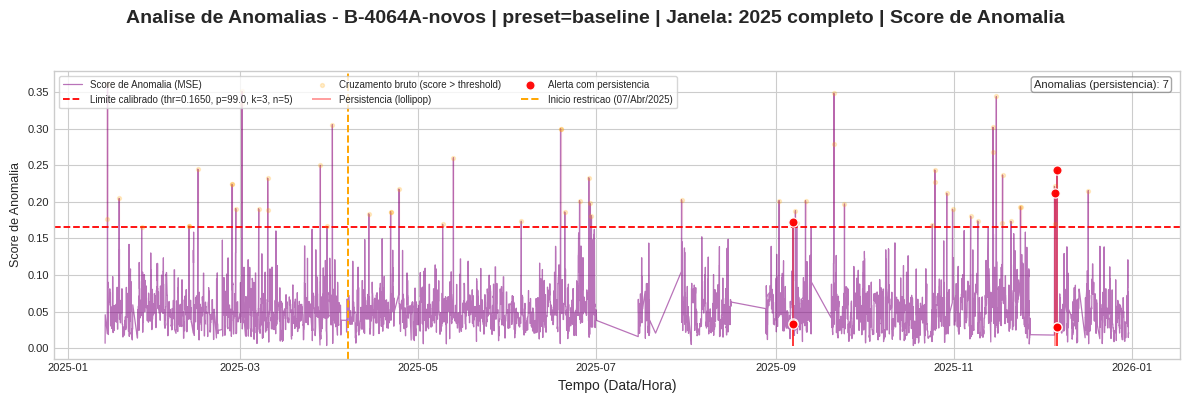

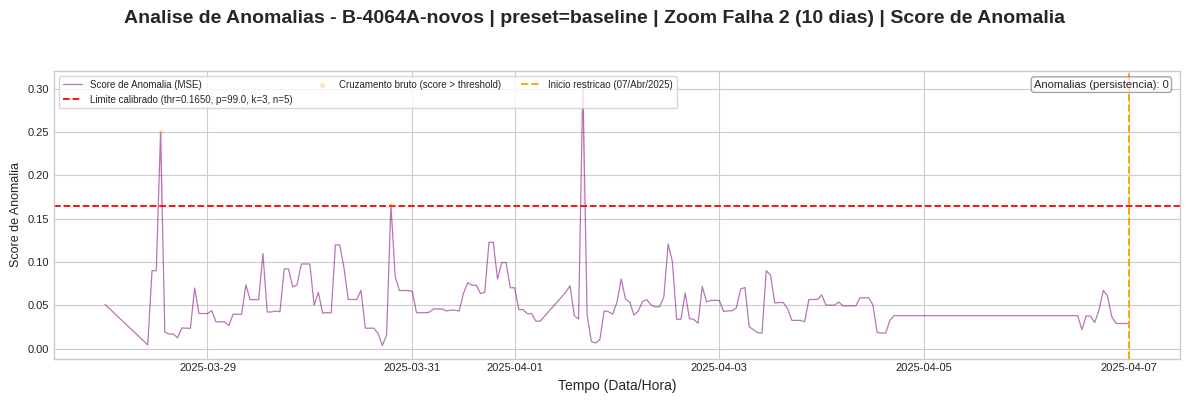


Preset: moving_average | Task: 89d98de34bb642009b0a552b1747b0e1 | Artifact de score: full_scores
Threshold em results: 0.031891
Sensibilidade calibrada: threshold=0.120962, percentile=99.0, k=3, n=5, alerts/day=0.050


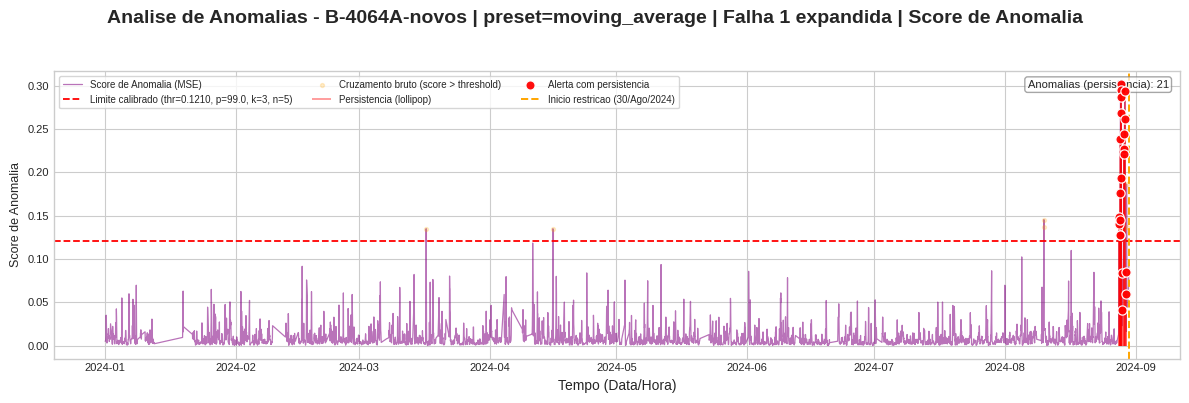

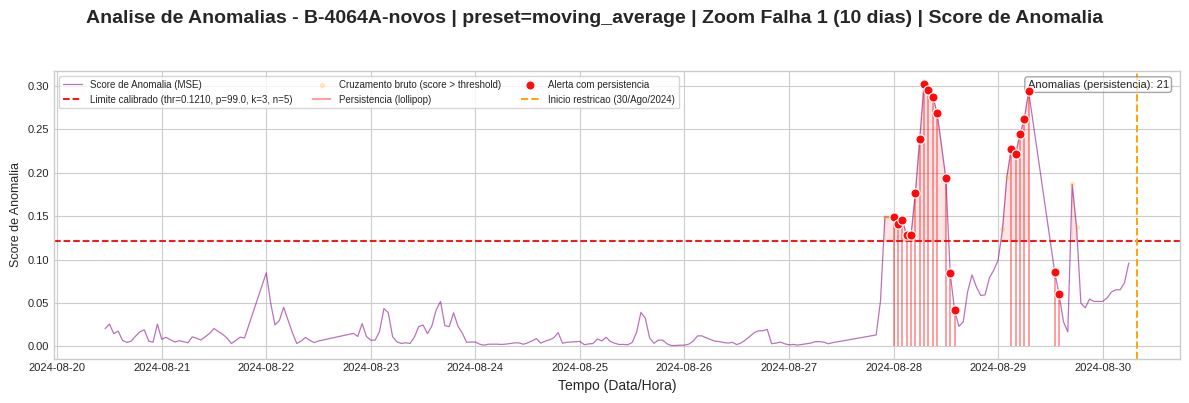

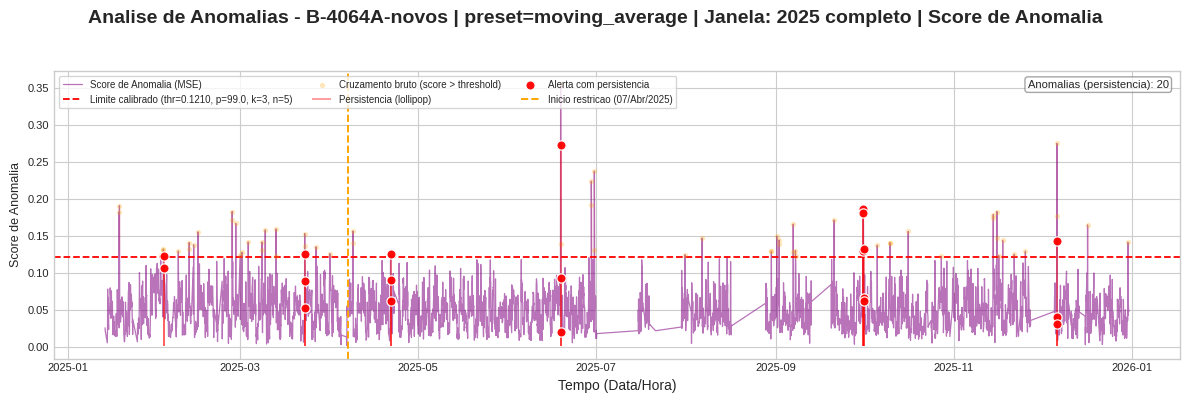

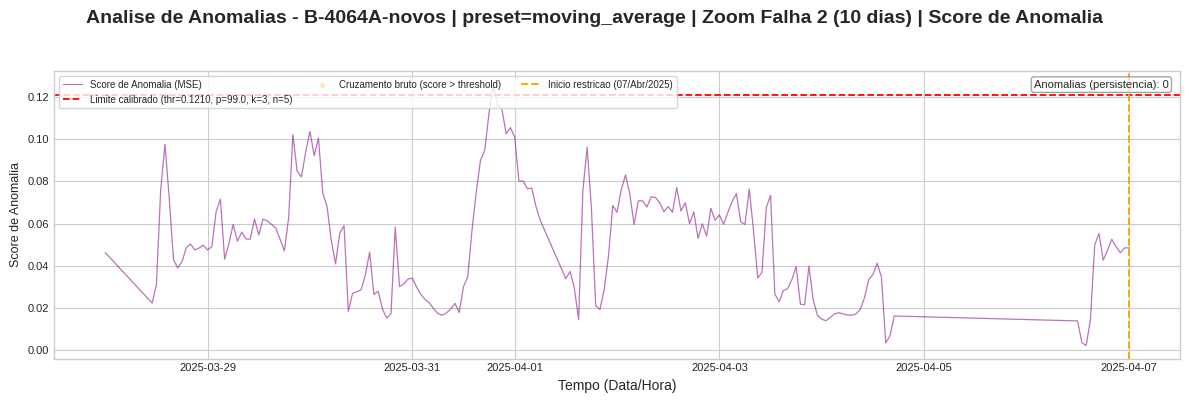


Preset: knn | Task: f1d52184727548bd90be2c4d98ad2971 | Artifact de score: full_scores
Threshold em results: 0.044684
Sensibilidade calibrada: threshold=0.165013, percentile=99.0, k=3, n=5, alerts/day=0.023


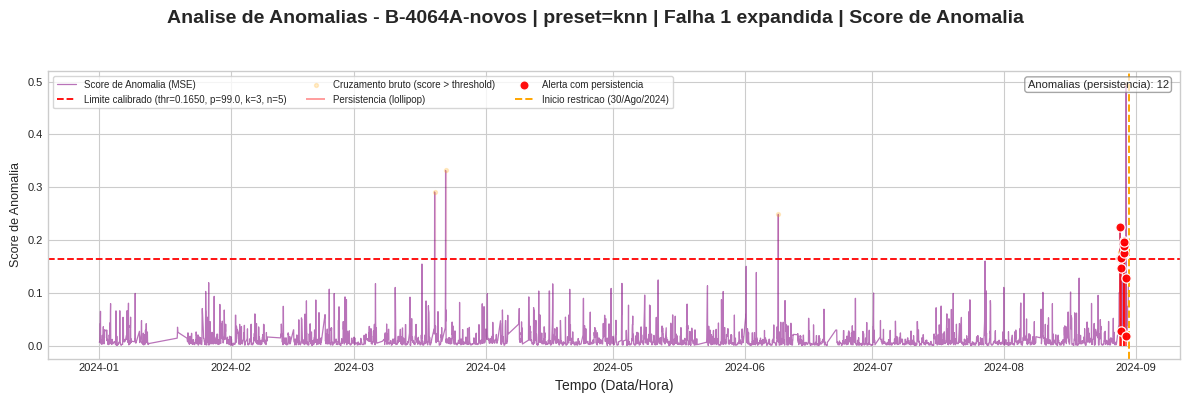

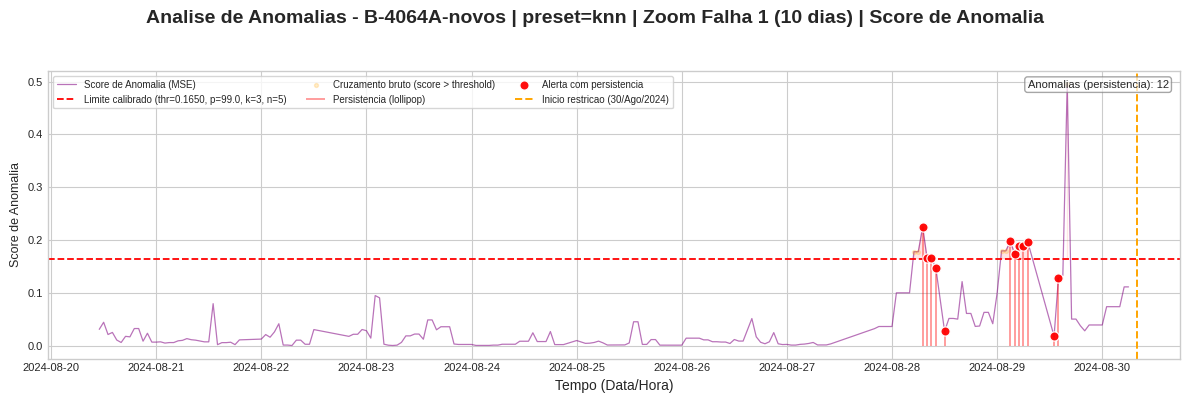

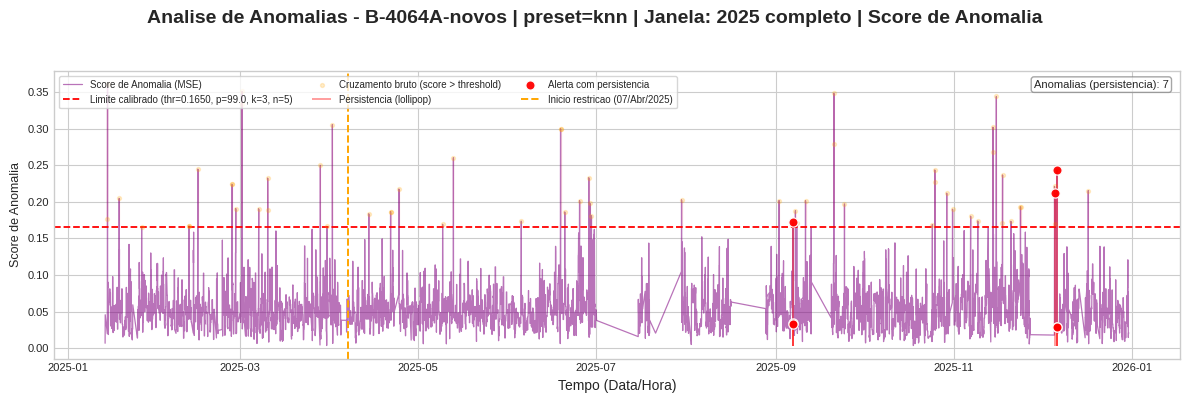

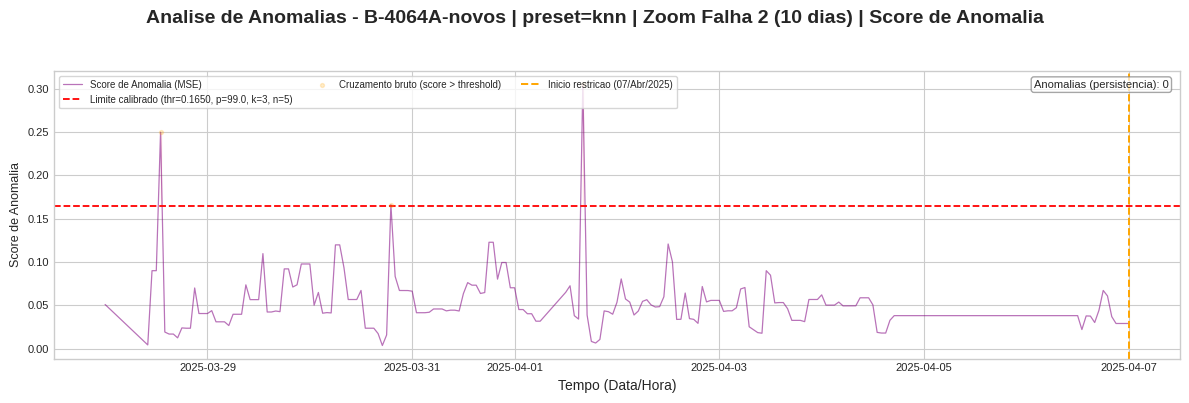


Preset: moving_average_knn | Task: d1495d0828d14580ac5ede921184525a | Artifact de score: full_scores
Threshold em results: 0.031891
Sensibilidade calibrada: threshold=0.120962, percentile=99.0, k=3, n=5, alerts/day=0.050


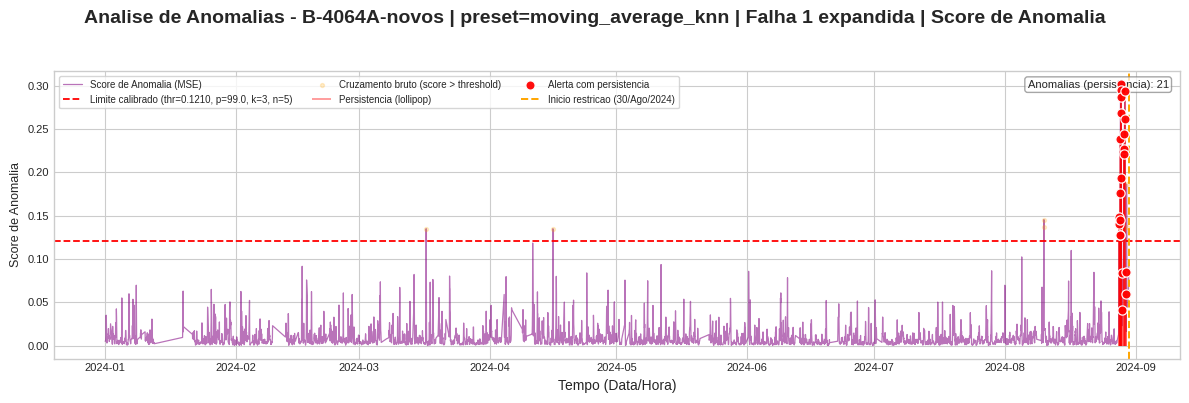

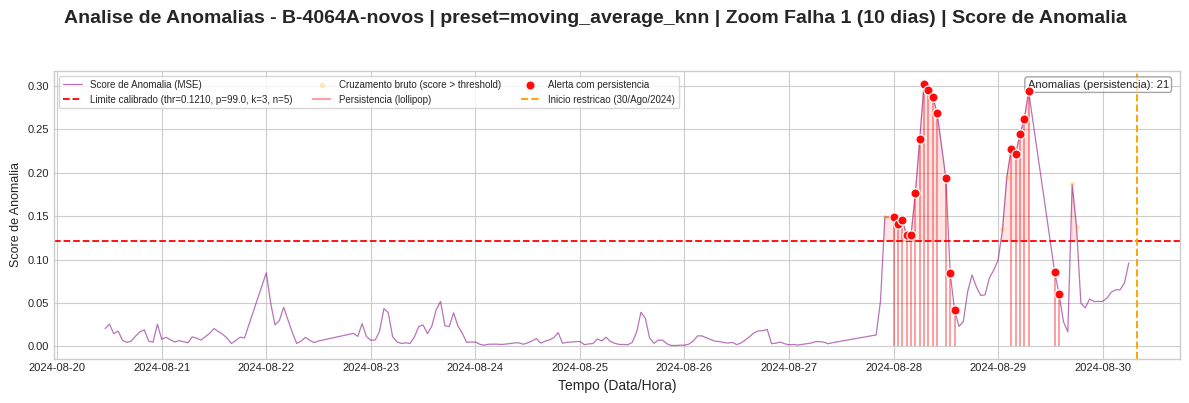

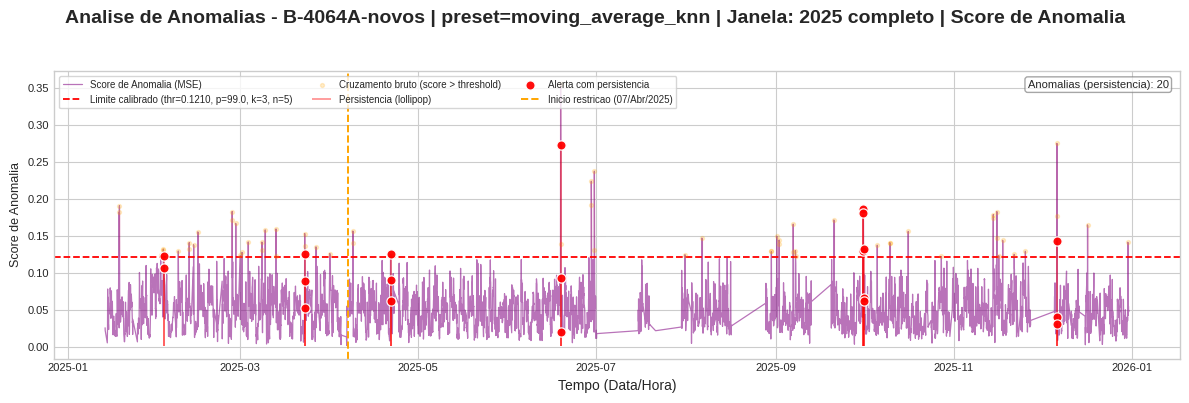

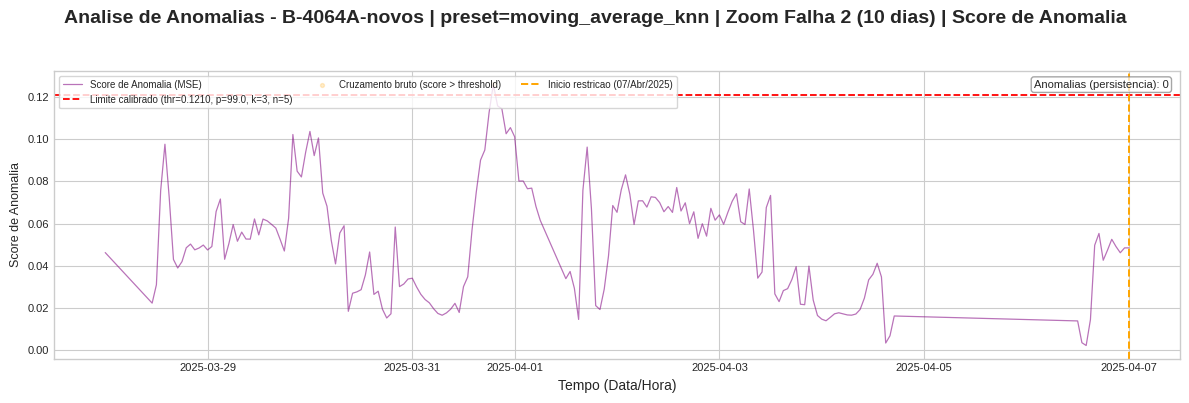


Resumo comparativo por preset (ordenado por score_rank):


,preset,task_id,score_artifact,threshold_base_results,threshold_efetivo,k,n,anomalias_prox_falha1,dens_anomalias_prox_falha1,anomalias_prox_falha2,dens_anomalias_prox_falha2,falsos_positivos_2025_calib,n_samples_2025_calib,taxa_fp_2025_calib,anomalias_2025_total,n_samples_2025_total,taxa_fp_2025,score_rank,rank
0,moving_average,89d98de34bb642009b0a552b1747b0e1,full_scores,0.031891,0.120962,3,5,21,0.101942,0,0.0,12,4288,0.002799,20,6569,0.003045,0.247489,1
1,moving_average_knn,d1495d0828d14580ac5ede921184525a,full_scores,0.031891,0.120962,3,5,21,0.101942,0,0.0,12,4288,0.002799,20,6569,0.003045,0.247489,2
2,baseline,f2ba460471bf45639652fc94b6214a7a,full_scores,0.044684,0.165013,3,5,12,0.058252,0,0.0,7,4288,0.001632,7,6569,0.001066,0.142400,3
3,knn,f1d52184727548bd90be2c4d98ad2971,full_scores,0.044684,0.165013,3,5,12,0.058252,0,0.0,7,4288,0.001632,7,6569,0.001066,0.142400,4



Resumo por janela (todas as execucoes):


,preset,task_id,janela,inicio,fim,n_samples,n_anomalies,pct_anomalies,threshold,k,n,arquivos
0,baseline,f2ba460471bf45639652fc94b6214a7a,Falha 1 expandida,2024-01-01 01:00:00,2024-08-30 07:58:00,4890,12,0.25,0.165013,3,5,
1,baseline,f2ba460471bf45639652fc94b6214a7a,Zoom Falha 1 (10 dias),2024-08-20 07:58:00,2024-08-30 07:58:00,206,12,5.83,0.165013,3,5,
2,baseline,f2ba460471bf45639652fc94b6214a7a,Ano 2025 completo,2025-01-01 00:00:00,2025-12-31 00:00:00,6569,7,0.11,0.165013,3,5,
3,baseline,f2ba460471bf45639652fc94b6214a7a,Zoom Falha 2 (10 dias),2025-03-28 00:00:00,2025-04-07 00:00:00,185,0,0.00,0.165013,3,5,
4,moving_average,89d98de34bb642009b0a552b1747b0e1,Falha 1 expandida,2024-01-01 01:00:00,2024-08-30 07:58:00,4890,21,0.43,0.120962,3,5,
5,moving_average,89d98de34bb642009b0a552b1747b0e1,Zoom Falha 1 (10 dias),2024-08-20 07:58:00,2024-08-30 07:58:00,206,21,10.19,0.120962,3,5,
6,moving_average,89d98de34bb642009b0a552b1747b0e1,Ano 2025 completo,2025-01-01 00:00:00,2025-12-31 00:00:00,6569,20,0.30,0.120962,3,5,
7,moving_average,89d98de34bb642009b0a552b1747b0e1,Zoom Falha 2 (10 dias),2025-03-28 00:00:00,2025-04-07 00:00:00,185,0,0.00,0.120962,3,5,
8,knn,f1d52184727548bd90be2c4d98ad2971,Falha 1 expandida,2024-01-01 01:00:00,2024-08-30 07:58:00,4890,12,0.25,0.165013,3,5,
9,knn,f1d52184727548bd90be2c4d98ad2971,Zoom Falha 1 (10 dias),2024-08-20 07:58:00,2024-08-30 07:58:00,206,12,5.83,0.165013,3,5,


CSV comparativo salvo em: /home/chico/Documentos/ciencia-dados/Transpetro-modelos/notebooks/comparativo_setups_b4064a_novos.csv
CSV de janelas salvo em: /home/chico/Documentos/ciencia-dados/Transpetro-modelos/notebooks/comparativo_setups_b4064a_novos_janelas.csv

Recomendacao automatica de setup:
Melhor preset: moving_average | task_id=89d98de34bb642009b0a552b1747b0e1 | score_rank=0.247489
Motivo: maior deteccao perto das falhas com penalidade de falso positivo em 2025 e na janela de calibracao.


In [20]:
df_base, config = load_plot_base(EQUIPMENT_ID)
print_preprocessing_confirmation(config)
print()

resolved_task_ids = resolve_task_ids_by_preset()
print('Mapa preset -> task_id resolvido:')
for p in PRESETS_TARGET:
    print(f'  - {p}: {resolved_task_ids[p]}')

# Validacao task base de moving_average
base_task, base_results, _, _, _ = load_task_outputs(
    resolved_task_ids['moving_average'],
    use_full_scores=USE_FULL_SCORES,
)
base_preset = str(base_results.get('preprocess_preset', '')).strip().lower()
if base_preset and base_preset != 'moving_average':
    raise ValueError(
        f'Task base ({base_task.id}) nao eh moving_average. preprocess_preset encontrado: {base_preset}'
    )

preset_summaries = []
window_summaries = []

for preset in PRESETS_TARGET:
    task_id = resolved_task_ids[preset]
    task, results, threshold_from_results, scores, score_artifact_name = load_task_outputs(
        task_id,
        use_full_scores=USE_FULL_SCORES,
    )

    print('\n' + '=' * 90)
    print(f'Preset: {preset} | Task: {task.id} | Artifact de score: {score_artifact_name}')
    print(f"Threshold em results: {threshold_from_results:.6f}")

    eff_percentiles, eff_grid, eff_target_alerts = choose_sensitivity_params(SENSITIVITY_PRESET)

    if AUTO_USE_CALIBRATED_SENSITIVITY:
        sens = recommend_sensitivity(
            scores=scores,
            calib_start=CALIB_START,
            calib_end=CALIB_END,
            calib_percentiles=eff_percentiles,
            calib_grid=eff_grid,
            target_alerts_per_day=eff_target_alerts,
        )
        selected_threshold = float(THRESHOLD_OVERRIDE) if THRESHOLD_OVERRIDE is not None else float(sens['threshold'])
        selected_k = int(sens['k'])
        selected_n = int(sens['n'])
        threshold_label = (
            f"Limite calibrado (thr={selected_threshold:.4f}, p={sens['percentile']:.1f}, k={selected_k}, n={selected_n})"
        )
        print(
            f"Sensibilidade calibrada: threshold={selected_threshold:.6f}, percentile={sens['percentile']:.1f}, "
            f"k={selected_k}, n={selected_n}, alerts/day={sens['alerts_per_day']:.3f}"
        )
    else:
        selected_threshold = float(THRESHOLD_OVERRIDE) if THRESHOLD_OVERRIDE is not None else float(threshold_from_results)
        selected_k = 1
        selected_n = 1
        threshold_label = f'Limite (threshold = {selected_threshold:.4f})'

    threshold_flags_all = scores['reconstruction_error'] > selected_threshold
    anomaly_flags_all = persistence_filter(threshold_flags_all, k=selected_k, n=selected_n)

    # Metricas globais para ranking
    _, anom_f1, dens_f1 = compute_window_metrics(scores, anomaly_flags_all, WINDOW_F1_ZOOM_START, WINDOW_F1_ZOOM_END)
    _, anom_f2, dens_f2 = compute_window_metrics(scores, anomaly_flags_all, WINDOW_F2_ZOOM_START, WINDOW_F2_ZOOM_END)
    n_calib, fp_calib, taxa_fp_calib = compute_window_metrics(scores, anomaly_flags_all, CALIB_START, CALIB_END)
    n_2025, anom_2025, taxa_fp_2025 = compute_window_metrics(scores, anomaly_flags_all, WINDOW_2025_START, WINDOW_2025_END)

    summary_row = {
        'preset': preset,
        'task_id': task.id,
        'score_artifact': score_artifact_name,
        'threshold_base_results': float(threshold_from_results),
        'threshold_efetivo': float(selected_threshold),
        'k': int(selected_k),
        'n': int(selected_n),
        'anomalias_prox_falha1': int(anom_f1),
        'dens_anomalias_prox_falha1': float(dens_f1),
        'anomalias_prox_falha2': int(anom_f2),
        'dens_anomalias_prox_falha2': float(dens_f2),
        'falsos_positivos_2025_calib': int(fp_calib),
        'n_samples_2025_calib': int(n_calib),
        'taxa_fp_2025_calib': float(taxa_fp_calib),
        'anomalias_2025_total': int(anom_2025),
        'n_samples_2025_total': int(n_2025),
        'taxa_fp_2025': float(taxa_fp_2025),
    }

    # Plots no mesmo padrao do notebook atual (4 janelas)
    safe_task_id = task.id.replace('/', '_').replace(':', '_')
    windows = [
        {
            'name': 'Falha 1 expandida',
            'slug': 'falha1_expandida',
            'start': scores.index.min(),
            'end': EVENT_TS_F1,
            'event_date': EVENT_DATE_F1,
            'event_label': EVENT_LABEL_F1,
            'title': f'Analise de Anomalias - {EQUIPMENT_ID} | preset={preset} | Falha 1 expandida',
        },
        {
            'name': 'Zoom Falha 1 (10 dias)',
            'slug': 'falha1_zoom10',
            'start': WINDOW_F1_ZOOM_START,
            'end': WINDOW_F1_ZOOM_END,
            'event_date': EVENT_DATE_F1,
            'event_label': EVENT_LABEL_F1,
            'title': f'Analise de Anomalias - {EQUIPMENT_ID} | preset={preset} | Zoom Falha 1 (10 dias)',
        },
        {
            'name': 'Ano 2025 completo',
            'slug': '2025_full',
            'start': WINDOW_2025_START,
            'end': WINDOW_2025_END,
            'event_date': EVENT_DATE_F2,
            'event_label': EVENT_LABEL_F2,
            'title': f'Analise de Anomalias - {EQUIPMENT_ID} | preset={preset} | Janela: 2025 completo',
        },
        {
            'name': 'Zoom Falha 2 (10 dias)',
            'slug': '2025_falha2_zoom10',
            'start': WINDOW_F2_ZOOM_START,
            'end': WINDOW_F2_ZOOM_END,
            'event_date': EVENT_DATE_F2,
            'event_label': EVENT_LABEL_F2,
            'title': f'Analise de Anomalias - {EQUIPMENT_ID} | preset={preset} | Zoom Falha 2 (10 dias)',
        },
    ]

    for w in windows:
        df_window, scores_window = slice_window(df_base, scores, w['start'], w['end'])
        thr_flags = threshold_flags_all.loc[scores_window.index]
        anom_flags = anomaly_flags_all.loc[scores_window.index]
        n_anom = int(anom_flags.sum())

        out_path = PROJECT_ROOT / 'notebooks' / (
            f"anomalias_b4064a_{preset}_{w['slug']}_{safe_task_id}.png"
        )

        effective_save_plots = bool(SAVE_PLOTS and GENERATE_PLOTS)
        if not GENERATE_PLOTS:
            saved_paths = []
        elif PLOT_ONLY_SCORES:
            saved_paths = plot_score_only_panel(
                scores_window=scores_window,
                threshold_flags=thr_flags,
                anomaly_flags=anom_flags,
                threshold=selected_threshold,
                threshold_label=threshold_label,
                n_anomalies=n_anom,
                event_date=pd.Timestamp(w['event_date']),
                event_label=w['event_label'],
                title=w['title'],
                output_path=out_path,
                dpi=OUTPUT_DPI,
                save_plots=effective_save_plots,
                anomaly_highlight_style=ANOMALY_HIGHLIGHT_STYLE,
            )
        else:
            saved_paths = plot_anomaly_panels(
                df_window=df_window,
                scores_window=scores_window,
                threshold_flags=thr_flags,
                anomaly_flags=anom_flags,
                threshold=selected_threshold,
                threshold_label=threshold_label,
                n_anomalies=n_anom,
                event_date=pd.Timestamp(w['event_date']),
                event_label=w['event_label'],
                title=w['title'],
                output_path=out_path,
                dpi=OUTPUT_DPI,
                plot_mode=PLOT_MODE,
                save_plots=effective_save_plots,
                anomaly_highlight_style=ANOMALY_HIGHLIGHT_STYLE,
            )

        n_samples = len(scores_window)
        pct_anom = (100.0 * n_anom / n_samples) if n_samples else 0.0
        window_summaries.append(
            {
                'preset': preset,
                'task_id': task.id,
                'janela': w['name'],
                'inicio': pd.Timestamp(w['start']),
                'fim': pd.Timestamp(w['end']),
                'n_samples': int(n_samples),
                'n_anomalies': int(n_anom),
                'pct_anomalies': round(pct_anom, 2),
                'threshold': float(selected_threshold),
                'k': int(selected_k),
                'n': int(selected_n),
                'arquivos': ', '.join(str(x) for x in saved_paths) if (SAVE_PLOTS and GENERATE_PLOTS) else '',
            }
        )

    preset_summaries.append(summary_row)

comparativo_df = pd.DataFrame(preset_summaries)
comparativo_df['score_rank'] = comparativo_df.apply(compute_score_rank, axis=1)
comparativo_df = comparativo_df.sort_values('score_rank', ascending=False).reset_index(drop=True)
comparativo_df['rank'] = np.arange(1, len(comparativo_df) + 1)

print('\nResumo comparativo por preset (ordenado por score_rank):')
display(comparativo_df)

windows_df = pd.DataFrame(window_summaries)
print('\nResumo por janela (todas as execucoes):')
display(windows_df)

if SAVE_COMPARISON_CSV:
    COMPARISON_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    comparativo_df.to_csv(COMPARISON_CSV_PATH, index=False)
    windows_csv = COMPARISON_CSV_PATH.with_name(COMPARISON_CSV_PATH.stem + '_janelas.csv')
    windows_df.to_csv(windows_csv, index=False)
    print('CSV comparativo salvo em:', COMPARISON_CSV_PATH)
    print('CSV de janelas salvo em:', windows_csv)

if not comparativo_df.empty:
    vencedor = comparativo_df.iloc[0]
    print('\nRecomendacao automatica de setup:')
    print(
        f"Melhor preset: {vencedor['preset']} | task_id={vencedor['task_id']} | "
        f"score_rank={vencedor['score_rank']:.6f}"
    )
    print(
        'Motivo: maior deteccao perto das falhas com penalidade de falso positivo em 2025 e na janela de calibracao.'
    )
